In [163]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
parent_dir = "/home/connorlab/Documents/GitHub/Julie/social_data/zombies_social_data/"
# Load data
aff_df = pd.read_excel(parent_dir + "zombies_feature_df_affiliation.xlsx", index_col=0)
sub_df = pd.read_excel(parent_dir + "zombies_feature_df_submission.xlsx", index_col=0)
ago_df = pd.read_excel(parent_dir + "zombies_feature_df_agonism.xlsx", index_col=0)

In [164]:
# 함수: "Behavior Towards 94B" → "94B"
def clean_col(colname):
    return colname.split()[-1]  # 마지막 단어만 추출

# 컬럼 이름 정리
aff_df.columns = [clean_col(c) for c in aff_df.columns]
sub_df.columns = [clean_col(c) for c in sub_df.columns]
ago_df.columns = [clean_col(c) for c in ago_df.columns]


# 공통 monkey 추출
monkeys = aff_df.index.intersection(sub_df.index).intersection(ago_df.index)

In [216]:
# Build behavior vector per monkey (row-wise vector from each matrix)
# X = []
# for m in monkeys:
#     v = np.concatenate([
#         aff_df.loc[m].values,
#         sub_df.loc[m].values,
#         ago_df.loc[m].values
#     ])
#     X.append(v)
# X = np.array(X)
# X

aff = np.array(aff_df)
ago = np.array(ago_df)
sub = np.array(sub_df)

In [231]:
X = aff
X

array([[ 0, 19,  9, 38, 84, 27, 13, 14,  4,  9],
       [15,  0,  9, 41,  4, 13, 19, 71, 12,  0],
       [18, 10,  0, 21,  7, 17, 49, 18,  3,  1],
       [38, 43, 24,  0, 18,  6, 31, 26, 29,  4],
       [90,  3,  8,  8,  0, 22,  8,  9,  1, 18],
       [23, 12, 17,  1, 23,  0, 23, 16,  3, 10],
       [17, 18, 43, 34, 10, 23,  0, 34,  2,  9],
       [11, 70, 18, 17,  8, 17, 33,  0,  5,  3],
       [ 3,  6,  4, 31,  2,  1,  2,  4,  0,  9],
       [ 8,  0,  0,  1, 26,  8,  2,  1,  7,  0]])

In [232]:
from analyses.spike_rate import compute_mean_spike_rate_for_windows
from analyses.enums.monkey_names import get_monkeys_by_default_order
import pandas as pd
monkey_group = "Zombies"
subject_monkey_index = 6
monkey_list = get_monkeys_by_default_order(monkey_group)
sig_windows = pd.read_pickle(
        f'/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_cache/{monkey_group}_significant_windows_pANOVAorGLM_passed.pkl')
ed_sig_windows = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/used_for_R01/R01_ed_list_duplicate_removed_without_full_window.pkl')
mean_spike_rate_windows = compute_mean_spike_rate_for_windows(ed_sig_windows)

Computing windowed mean spike rate: 100%|██████████| 57/57 [00:01<00:00, 47.68it/s]


In [233]:
spike_rate = mean_spike_rate_windows[mean_spike_rate_windows['MonkeyGroup']=='Zombies']
spike_rate = spike_rate[spike_rate['MonkeyName']!='NewMonkey']
# spike_rate = spike_rate[spike_rate['MonkeyName']!='7124']
spike_rate['MonkeyName'].unique()

array(['110E', '143H', '151J', '67G', '69X', '7124', '72X', '87J', '94B'],
      dtype=object)

In [234]:
def run_simple_pca_regression(spike_df, pca_df, n_components=3):
    import statsmodels.api as sm
    from tqdm import tqdm

    results = []

    grouped = spike_df.groupby(['NeuronID', 'WindowStart_ms', 'WindowEnd_ms'])

    for (neuron_id, w_start, w_end), group in tqdm(grouped, desc='Running PCA regressions'):
        group = group.set_index('MonkeyName')
        monkeys_in_window = group.index.intersection(pca_df.index)

        if len(monkeys_in_window) < n_components + 2:
            continue  # not enough data

        y = group.loc[monkeys_in_window, 'MeanSpikeRate'].values
        X = pca_df.loc[monkeys_in_window, [f'Feature{i+1}' for i in range(n_components)]].values
        X = sm.add_constant(X)

        try:
            model = sm.OLS(y, X).fit()
            results.append({
                'NeuronID': neuron_id,
                'WindowStart_ms': w_start,
                'WindowEnd_ms': w_end,
                'R_squared': model.rsquared,
                'p_values': model.pvalues.tolist(),
                'coefficients': model.params.tolist()
            })
        except Exception as e:
            print(f"{neuron_id} ({w_start}-{w_end}) failed: {e}")
            continue

    return pd.DataFrame(results)


In [235]:
X_df = pd.DataFrame(X, index=monkey_list, columns=[f'Feature{i+1}' for i in range(X.shape[1])])

In [236]:
X_df_clean = X_df.drop(index="81G")
X_df_clean

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
7124,0,19,9,38,84,27,13,14,4,9
69X,15,0,9,41,4,13,19,71,12,0
72X,18,10,0,21,7,17,49,18,3,1
94B,38,43,24,0,18,6,31,26,29,4
110E,90,3,8,8,0,22,8,9,1,18
67G,23,12,17,1,23,0,23,16,3,10
143H,11,70,18,17,8,17,33,0,5,3
87J,3,6,4,31,2,1,2,4,0,9
151J,8,0,0,1,26,8,2,1,7,0


In [237]:
from analyses.linear_regression.multiple_linear_regression import run_simple_regression
results_df = run_simple_regression(spike_rate, X_df_clean)
results_df

Running regressions: 100%|██████████| 57/57 [00:00<00:00, 806.99it/s]


,NeuronID,WindowStart_ms,WindowEnd_ms,R_squared,p_values,coefficients
0,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[7.905342160447535, 1.7154302766805016, 0.5564..."
1,AMG_2023-09-26_2_Channel.C_011_Unit 1,700.0,1000.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4735716226467291, 0.0748665274169727, 0.079..."
2,AMG_2023-09-26_2_Channel.C_020,50.0,150.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[8.44294171236047, 1.5833752546331816, 0.84340..."
3,AMG_2023-09-26_3_Channel.C_007_Unit 2,100.0,200.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.35487143641024865, 0.06648900945403255, 0.0..."
4,AMG_2023-09-26_3_Channel.C_027_Unit 2,150.0,350.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[25.723117990847562, 5.129061138875543, 2.0507..."
5,AMG_2023-10-03_3_Channel.C_006_Unit 1,200.0,400.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4557414378411593, 0.11780478864251016, 0.03..."
6,AMG_2023-10-03_3_Channel.C_006_Unit 1,2150.0,2250.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.672836888038171, 0.12188171132955745, 0.148..."
7,AMG_2023-10-03_3_Channel.C_013_Unit 1,200.0,600.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[5.4627857362720125, 1.069476186919957, 0.4227..."
8,AMG_2023-10-03_3_Channel.C_026_Unit 1,1900.0,2000.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[1.7647285484842539, 0.34216201265512997, 0.12..."
9,AMG_2023-10-03_4_Channel.C_006,450.0,650.0,1.0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[6.173253232119747, 1.1554053759033718, 0.4743..."


In [238]:
results_df['NeuronWindowID']= (
    results_df['NeuronID'] + "_" 
    + results_df['WindowStart_ms'].astype(str) + "_"
    + results_df['WindowEnd_ms'].astype(str)
)

In [239]:
# import matplotlib.pyplot as plt
# %matplotlib inline
# plt.figure(figsize=(6, 4))
# plt.hist(results_df['R_squared'], bins=30, color='gray', edgecolor='black')
# plt.xlabel('R-squared')
# plt.ylabel('Number of Windows')
# plt.title('Distribution of R² across Neuron × Window')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [240]:
# threshold = 0.6
# n_sig = (results_df['R_squared'] > threshold).sum()
# n_total = len(results_df)
# 
# print(f"{n_sig} out of {n_total} windows had R² > {threshold:.2f} ({n_sig / n_total:.1%})")

In [241]:
# import pandas as pd
# import matplotlib.pyplot as plt
# 
# # Convert list of coefficients into a DataFrame
# coeff_df = pd.DataFrame(results_df['coefficients'].tolist(),
#                         index=results_df.index)
# 
# # Plotting all coefficient vectors as lines
# plt.figure(figsize=(10, 6))
# for i, row in coeff_df.iterrows():
#     plt.plot(row.values, alpha=0.5, label=f'{results_df.iloc[i]["NeuronID"]}' if i < 10 else "")  # label only first few
# plt.xlabel("Predictor Index")
# plt.ylabel("Coefficient Value")
# plt.title("Regression Coefficients Across Neurons")
# plt.grid(True)
# plt.axhline(0, color='black', linestyle='--')
# plt.tight_layout()
# plt.legend(loc="best", fontsize=8)
# plt.show()

In [242]:
results_df[['NeuronWindowID','coefficients']]

,NeuronWindowID,coefficients
0,AMG_2023-09-26_1_Channel.C_027_Unit 1_0.0_300.0,"[7.905342160447535, 1.7154302766805016, 0.5564..."
1,AMG_2023-09-26_2_Channel.C_011_Unit 1_700.0_10...,"[0.4735716226467291, 0.0748665274169727, 0.079..."
2,AMG_2023-09-26_2_Channel.C_020_50.0_150.0,"[8.44294171236047, 1.5833752546331816, 0.84340..."
3,AMG_2023-09-26_3_Channel.C_007_Unit 2_100.0_200.0,"[0.35487143641024865, 0.06648900945403255, 0.0..."
4,AMG_2023-09-26_3_Channel.C_027_Unit 2_150.0_350.0,"[25.723117990847562, 5.129061138875543, 2.0507..."
5,AMG_2023-10-03_3_Channel.C_006_Unit 1_200.0_400.0,"[0.4557414378411593, 0.11780478864251016, 0.03..."
6,AMG_2023-10-03_3_Channel.C_006_Unit 1_2150.0_2...,"[0.672836888038171, 0.12188171132955745, 0.148..."
7,AMG_2023-10-03_3_Channel.C_013_Unit 1_200.0_600.0,"[5.4627857362720125, 1.069476186919957, 0.4227..."
8,AMG_2023-10-03_3_Channel.C_026_Unit 1_1900.0_2...,"[1.7647285484842539, 0.34216201265512997, 0.12..."
9,AMG_2023-10-03_4_Channel.C_006_450.0_650.0,"[6.173253232119747, 1.1554053759033718, 0.4743..."


In [245]:
X_df_clean

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
7124,0,19,9,38,84,27,13,14,4,9
69X,15,0,9,41,4,13,19,71,12,0
72X,18,10,0,21,7,17,49,18,3,1
94B,38,43,24,0,18,6,31,26,29,4
110E,90,3,8,8,0,22,8,9,1,18
67G,23,12,17,1,23,0,23,16,3,10
143H,11,70,18,17,8,17,33,0,5,3
87J,3,6,4,31,2,1,2,4,0,9
151J,8,0,0,1,26,8,2,1,7,0


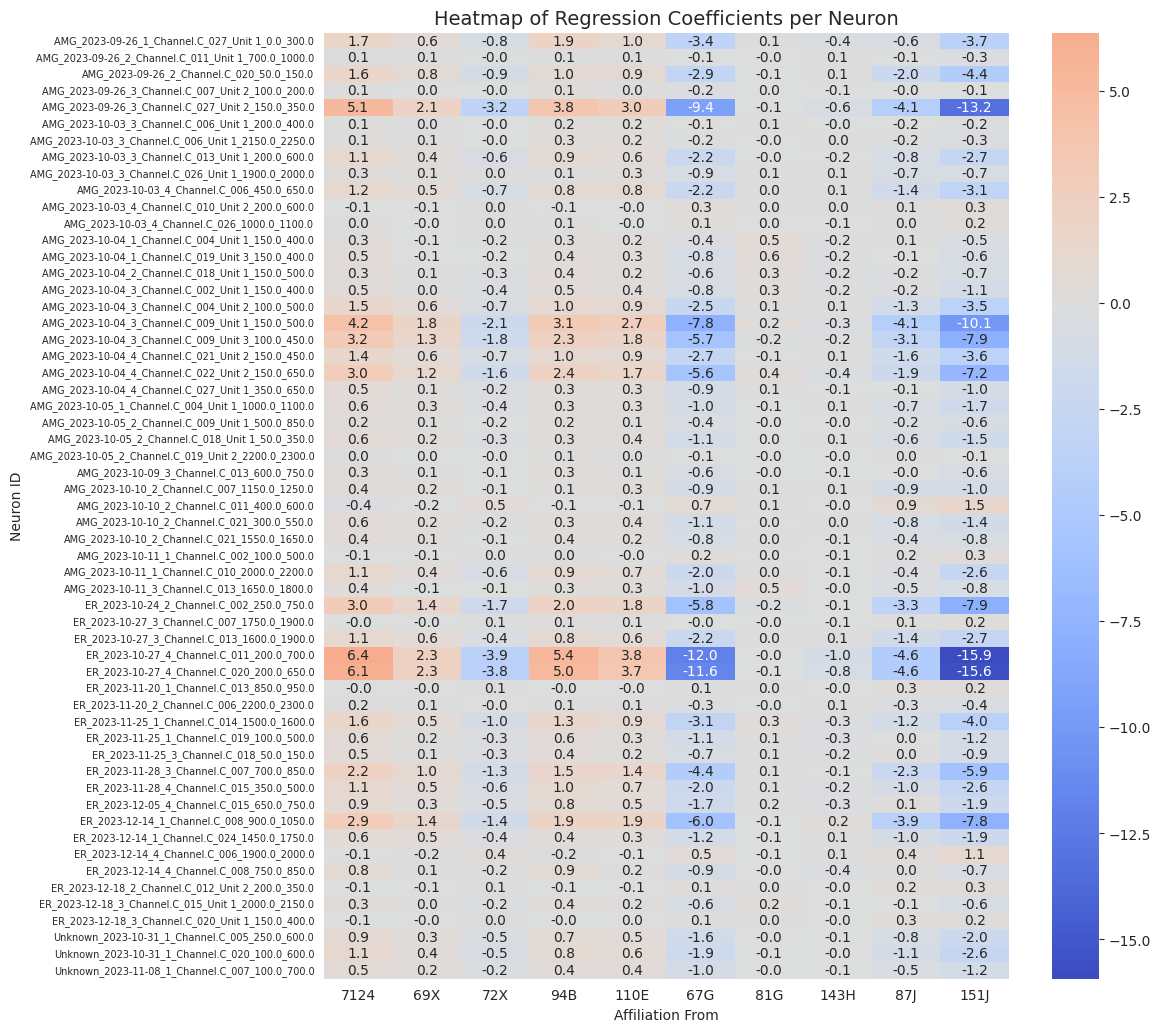

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the coefficients column as a new DataFrame
coeff_df = pd.DataFrame(results_df['coefficients'].tolist(),
                        index=results_df['NeuronWindowID']) 

filtered_monkey_list = [m for m in monkey_list if m not in ["81G"]]
coeff_df.columns = ['intercepts'] + monkey_list

plt.figure(figsize=(12, 10))
# ax = sns.heatmap(coeff_df, cmap='coolwarm', center=0, annot=True, fmt=".1f",
#                  yticklabels=True, cbar=True)
ax = sns.heatmap(coeff_df.iloc[:, 1:], cmap='coolwarm', center=0, annot=True, fmt=".1f",
                 yticklabels=True, cbar=True) # intercept removed


# Adjust label fonts AFTER the heatmap has rendered
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7, rotation=0)

# Fix for misalignment: force re-draw with tight layout
plt.tight_layout()
plt.title("Heatmap of Regression Coefficients per Neuron", fontsize=14)
plt.xlabel("Affiliation From")
plt.ylabel("Neuron ID")
plt.show()